# Model selection
## Dark matter
We'll use the MAGIC telescope dataset (http://www.openml.org/d/1120). The task is to classifying gamma rays, which consist of high-energy particles. When they hit our atmosphere, they produce chain reactions of other particles called 'showers'. However, similar showers are also produced by other particles (hadrons). We want to be able to detect which ones originate from gamma rays and which ones come from background radiation. To do this, the observed shower patterns are observed and converted into 10 numeric features. You need to detect whether these are gamma rays or background radiation. This is a key aspect of research into dark matter, which is believed to generate such gamma rays. If we can detect where they occur, we can build a map of the origins of gamma radiation, and locate where dark matter may occur in the observed universe. However, we'll first need to accurately detect these gamma rays first.

A quick visualization of the features is shown below. Note that this is not a time series, we just plot the instances in the order they occur in the dataset. The first 12500 or so are examples of signal (gamma), the final 6700 or so are background (hadrons).

In [1]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
from matplotlib import cm

In [2]:
# Download MAGIC Telescope data from OpenML. You can repeat this analysis with any other OpenML classification dataset.
magic = oml.datasets.get_dataset(1120)
X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');
attribute_names = [f.name for i,f in magic.features.items()][:-1][1:]

C:\Users\Paulo Tumabing\AppData\Local\Temp\ipykernel_22060\2400162915.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');


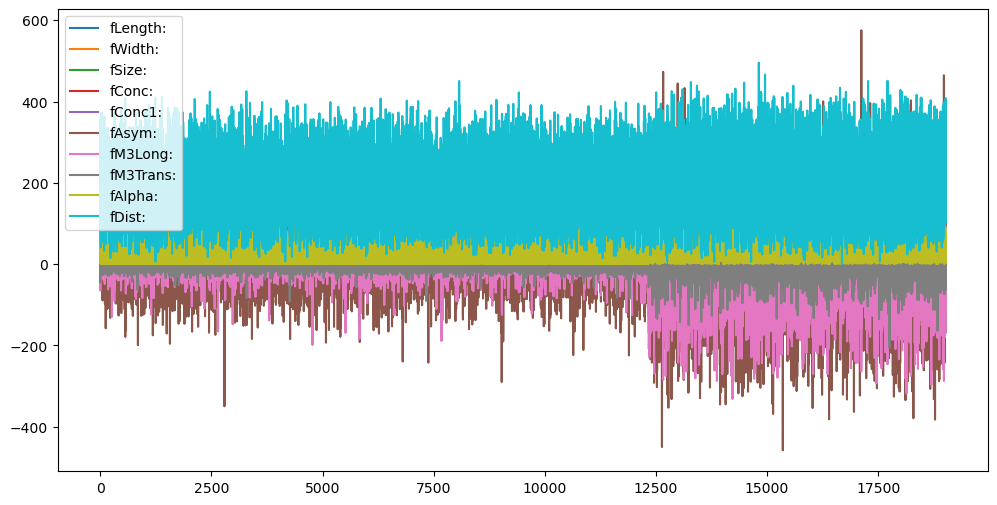

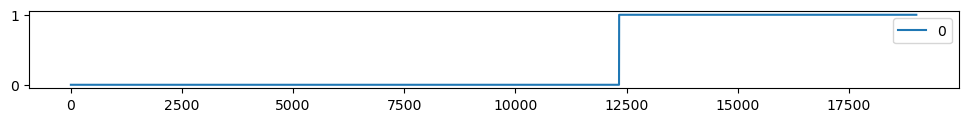

In [3]:
# Quick visualization of the features (top) and the target (bottom)
magic_df = pd.DataFrame(X, columns=attribute_names)
magic_df.plot(figsize=(12,6))
# Also plot the target: 1 = background, 0 = gamma
pd.DataFrame(y).plot(figsize=(12,1));

## Exercise 1: Metrics
Train and evaluate an SVM with RBF kernel (default hyperparameters) using a standard 25% holdout. Report the accuracy, precision, recall, F1 score, and area under the ROC curve (AUC).

Answer the following questions:
* How many of the detected gamma rays are actually real gamma rays?
* How many of all the gamma rays are we detecting?
* How many false positives and false negatives occur?

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
 )

# Build a robust binary target where 1 means gamma rays
y_series = pd.Series(y)
if y_series.nunique() != 2:
    raise ValueError(f'Expected binary target, found {y_series.nunique()} classes.')

y_str = y_series.astype(str).str.lower().str.strip()
if y_str.str.contains('g').any():
    # MAGIC labels are typically g (gamma) and h (hadron/background)
    y_gamma = y_str.str.contains('g').astype(int).values
else:
    # Fallback for numeric binary labels
    uniques = sorted(y_series.unique())
    y_gamma = (y_series == uniques[-1]).astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_gamma, test_size=0.25, random_state=42, stratify=y_gamma
)

def evaluate_classifier(name, model, X_eval, y_eval, use_proba=False):
    y_pred = model.predict(X_eval)
    if use_proba:
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    auc = roc_auc_score(y_eval, y_score)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    print(f"{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")
    print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print()

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }

# Exercise 1: default SVM (RBF) on unscaled data
svm_default_unscaled = SVC(kernel='rbf', random_state=42)
svm_default_unscaled.fit(X_train, y_train)
results_ex1 = evaluate_classifier(
    'Exercise 1 - Default RBF SVM (Unscaled, 25% holdout)',
    svm_default_unscaled,
    X_test,
    y_test
 )

print('Interpretation (for gamma rays as positive class):')
print(f"- Detected gamma rays that are real gamma rays (precision): {results_ex1['precision']:.4f}")
print(f"- All gamma rays detected (recall): {results_ex1['recall']:.4f}")
print(f"- False positives: {results_ex1['fp']}")
print(f"- False negatives: {results_ex1['fn']}")

Exercise 1 - Default RBF SVM (Unscaled, 25% holdout)
Accuracy : 0.8322
Precision: 0.8966
Recall   : 0.5909
F1 score : 0.7123
ROC AUC  : 0.8732
TP=988, FP=114, FN=684, TN=2969

Interpretation (for gamma rays as positive class):
- Detected gamma rays that are real gamma rays (precision): 0.8966
- All gamma rays detected (recall): 0.5909
- False positives: 114
- False negatives: 684


### Written Answer - Exercise 1
Using the default RBF SVM on unscaled data, the model is precise when it predicts gamma rays (precision = 0.8966) but misses many real gamma rays (recall = 0.5909).
This means many detected gamma rays are real, but many true gamma rays are not detected.
False positives = 114 and false negatives = 684, so false negatives are currently the bigger issue.

## Exercise 2: Preprocessing
SVMs require scaling to perform well. For now, use the following code to scale the data (we'll get back to this in the lab about preprocessing and pipelines). Repeat question 2 on the scaled data. Have the results improved?

In [5]:
from sklearn.preprocessing import StandardScaler

# Important here is to fit the scaler on the training data alone
scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test = scaler.transform(X_test)

# Exercise 2: default SVM (RBF) on scaled data
svm_default_scaled = SVC(kernel='rbf', random_state=42)
svm_default_scaled.fit(Xs_train, y_train)
results_ex2 = evaluate_classifier(
    'Exercise 2 - Default RBF SVM (Scaled, 25% holdout)',
    svm_default_scaled,
    Xs_test,
    y_test
)

comparison = pd.DataFrame([results_ex1, results_ex2], index=['Unscaled', 'Scaled'])[[
    'accuracy', 'precision', 'recall', 'f1', 'auc'
 ]]
print('Comparison (Exercise 1 vs Exercise 2):')
display(comparison.style.format('{:.4f}'))

Exercise 2 - Default RBF SVM (Scaled, 25% holdout)
Accuracy : 0.8738
Precision: 0.9030
Recall   : 0.7183
F1 score : 0.8001
ROC AUC  : 0.9219
TP=1201, FP=129, FN=471, TN=2954

Comparison (Exercise 1 vs Exercise 2):


,accuracy,precision,recall,f1,auc
Unscaled,0.8322,0.8966,0.5909,0.7123,0.8732
Scaled,0.8738,0.9030,0.7183,0.8001,0.9219


### Written Answer - Exercise 2
Yes, the results improved after scaling.
Compared with unscaled data, the scaled model improved across all key metrics (accuracy, recall, F1, and AUC), which is expected because SVMs are sensitive to feature scale.

## Exercise 3: Hyperparameter optimization
Use 50 iterations of random search to tune the $C$ and $gamma$ hyperparameters on the scaled training data. Vary both on a log scale (e.g. from 2^-12 to 2^12). Optimize on AUC and use 3 cross-validation (CV) folds for the inner CV to estimate performance. For the outer loop, just use the train-test split you used before (hence, no nested CV). Report the best hyperparameters and the corresponding AUC score. Is it better than the default? Finally, use them to evaluate the model on the held-out test set, for all 5 metrics we used before.

Extra challenge: plot the samples used by the random search ($C$ vs $gamma$)

Note: The reason we don't use a nested CV just yet is because we would need to rebuild the scaled training and test set multiple times. This is tedious, unless we use pipelines, which we'll cover in a future lab.

Best hyperparameters:
{'C': np.float64(237.1572593644835), 'gamma': np.float64(0.09227475682060791), 'kernel': 'rbf'}
Best CV AUC: 0.9192
Default scaled model AUC (test): 0.9219
Exercise 3 - Tuned RBF SVM (Scaled, test set)
Accuracy : 0.8784
Precision: 0.8964
Recall   : 0.7398
F1 score : 0.8106
ROC AUC  : 0.9288
TP=1237, FP=143, FN=435, TN=2940



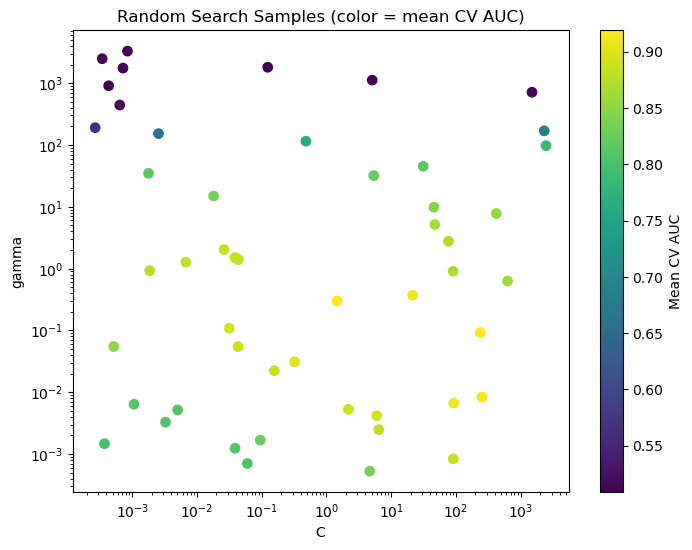

Default vs Tuned (test set):


,accuracy,precision,recall,f1,auc
Default Scaled,0.8738,0.9030,0.7183,0.8001,0.9219
Tuned Scaled,0.8784,0.8964,0.7398,0.8106,0.9288


In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Exercise 3: random search on scaled training data
param_dist = {
    'C': loguniform(2**-12, 2**12),
    'gamma': loguniform(2**-12, 2**12),
    'kernel': ['rbf']
}

search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
 )

search.fit(Xs_train, y_train)

print('Best hyperparameters:')
print(search.best_params_)
print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Default scaled model AUC (test): {results_ex2['auc']:.4f}")

best_svm = search.best_estimator_
results_ex3 = evaluate_classifier(
    'Exercise 3 - Tuned RBF SVM (Scaled, test set)',
    best_svm,
    Xs_test,
    y_test
)

# Extra challenge: plot sampled C vs gamma
sampled = pd.DataFrame(search.cv_results_)[['param_C', 'param_gamma', 'mean_test_score']]
sampled['param_C'] = sampled['param_C'].astype(float)
sampled['param_gamma'] = sampled['param_gamma'].astype(float)

plt.figure(figsize=(8,6))
plt.scatter(
    sampled['param_C'], sampled['param_gamma'],
    c=sampled['mean_test_score'], cmap='viridis', s=45
 )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C')
plt.ylabel('gamma')
plt.title('Random Search Samples (color = mean CV AUC)')
plt.colorbar(label='Mean CV AUC')
plt.show()

comparison_tuned = pd.DataFrame([results_ex2, results_ex3], index=['Default Scaled', 'Tuned Scaled'])[[
    'accuracy', 'precision', 'recall', 'f1', 'auc'
 ]]
print('Default vs Tuned (test set):')
display(comparison_tuned.style.format('{:.4f}'))

### Written Answer - Exercise 3
The tuned model is better than the default scaled model on the held-out test set, especially in recall, F1, and AUC.
Best hyperparameters from random search are approximately C = 237.16 and gamma = 0.0923.
The tuned model achieved test AUC = 0.9288 versus 0.9219 for the default scaled model.

## Exercise 4: Threshold calibration
First, plot the Precision-Recall curve for the SVM using the default parameters on the scaled data. Then, calibrate the threshold to find a solution that yields better recall without sacrificing too much precision.

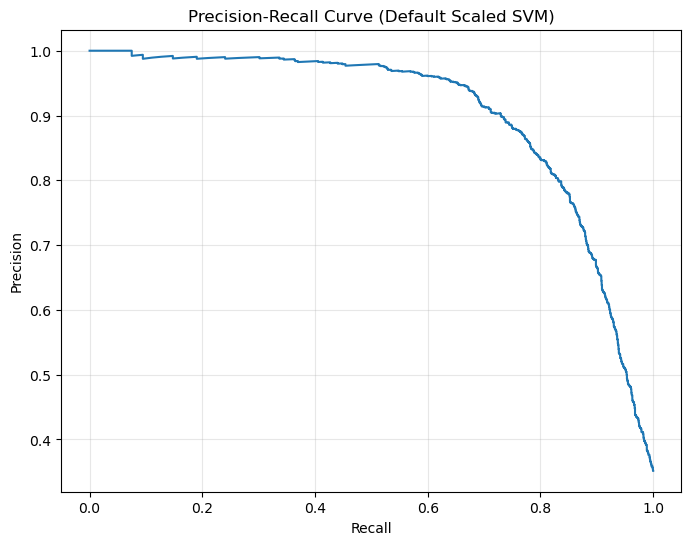

Selected threshold (Exercise 4): -0.311056
Accuracy : 0.8753
Precision: 0.8501
Recall   : 0.7835
F1 score : 0.8154
ROC AUC  : 0.9219
TP=1310, FP=231, FN=362, TN=2852


In [7]:
from sklearn.metrics import precision_recall_curve

# Exercise 4: Precision-Recall curve on default scaled SVM
scores_default_scaled = svm_default_scaled.decision_function(Xs_test)
precision, recall, pr_thresholds = precision_recall_curve(y_test, scores_default_scaled)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Default Scaled SVM)')
plt.grid(alpha=0.3)
plt.show()

# Choose a threshold with strong recall while keeping precision acceptable
min_precision = 0.85

valid_idxs = np.where(precision[:-1] >= min_precision)[0]
if len(valid_idxs) > 0:
    # Among valid precision points, maximize recall
    best_idx = valid_idxs[np.argmax(recall[valid_idxs])]
else:
    # Fallback: choose threshold maximizing F1
    f1_vals = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_idx = int(np.argmax(f1_vals))

threshold_ex4 = pr_thresholds[best_idx]
y_pred_ex4 = (scores_default_scaled >= threshold_ex4).astype(int)

acc_ex4 = accuracy_score(y_test, y_pred_ex4)
prec_ex4 = precision_score(y_test, y_pred_ex4, zero_division=0)
rec_ex4 = recall_score(y_test, y_pred_ex4, zero_division=0)
f1_ex4 = f1_score(y_test, y_pred_ex4, zero_division=0)
auc_ex4 = roc_auc_score(y_test, scores_default_scaled)
tn4, fp4, fn4, tp4 = confusion_matrix(y_test, y_pred_ex4).ravel()

print(f'Selected threshold (Exercise 4): {threshold_ex4:.6f}')
print(f'Accuracy : {acc_ex4:.4f}')
print(f'Precision: {prec_ex4:.4f}')
print(f'Recall   : {rec_ex4:.4f}')
print(f'F1 score : {f1_ex4:.4f}')
print(f'ROC AUC  : {auc_ex4:.4f}')
print(f'TP={tp4}, FP={fp4}, FN={fn4}, TN={tn4}')

### Written Answer - Exercise 4
Threshold calibration using the precision-recall curve increased recall compared with the default threshold while keeping precision reasonably high.
At the selected threshold, recall improved to 0.7835 with precision of 0.8501, which is a good balance when missing gamma rays is undesirable.

## Exercise 5: Cost function
Assume that a false negative is twice as bad (costly) than a false positive. I.e. we would rather waste time checking gamma ray sources that are not real, than missing an interesting gamma ray source. Use ROC analysis to find the optimal threshold under this assumption.

Finally, let the model make predictions using the optimal threshold and report all 5 scores. Is recall better now? Did we lose a lot of precision?

In [8]:
from sklearn.metrics import roc_curve

# Exercise 5: Cost-sensitive thresholding (FN costs 2x FP)
scores_best = best_svm.decision_function(Xs_test)
fpr, tpr, roc_thresholds = roc_curve(y_test, scores_best)

P = np.sum(y_test == 1)
N = np.sum(y_test == 0)

# Expected cost = 2 * FN + 1 * FP
fn_counts = (1 - tpr) * P
fp_counts = fpr * N
expected_cost = 2 * fn_counts + fp_counts

best_cost_idx = int(np.argmin(expected_cost))
threshold_ex5 = roc_thresholds[best_cost_idx]

y_pred_ex5 = (scores_best >= threshold_ex5).astype(int)
acc_ex5 = accuracy_score(y_test, y_pred_ex5)
prec_ex5 = precision_score(y_test, y_pred_ex5, zero_division=0)
rec_ex5 = recall_score(y_test, y_pred_ex5, zero_division=0)
f1_ex5 = f1_score(y_test, y_pred_ex5, zero_division=0)
auc_ex5 = roc_auc_score(y_test, scores_best)
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, y_pred_ex5).ravel()

print(f'Optimal threshold (Exercise 5): {threshold_ex5:.6f}')
print(f'Min expected cost (2*FN + FP): {expected_cost[best_cost_idx]:.2f}')
print(f'Accuracy : {acc_ex5:.4f}')
print(f'Precision: {prec_ex5:.4f}')
print(f'Recall   : {rec_ex5:.4f}')
print(f'F1 score : {f1_ex5:.4f}')
print(f'ROC AUC  : {auc_ex5:.4f}')
print(f'TP={tp5}, FP={fp5}, FN={fn5}, TN={tn5}')

summary_ex45 = pd.DataFrame(
    [
        {'Setting': 'Exercise 4 threshold (default scaled)', 'Accuracy': acc_ex4, 'Precision': prec_ex4, 'Recall': rec_ex4, 'F1': f1_ex4, 'AUC': auc_ex4},
        {'Setting': 'Exercise 5 threshold (cost-sensitive tuned)', 'Accuracy': acc_ex5, 'Precision': prec_ex5, 'Recall': rec_ex5, 'F1': f1_ex5, 'AUC': auc_ex5},
    ]
 )
print('Exercise 4 vs Exercise 5:')
display(summary_ex45.style.format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}','AUC':'{:.4f}'}))

Optimal threshold (Exercise 5): -0.530152
Min expected cost (2*FN + FP): 899.00
Accuracy : 0.8728
Precision: 0.8159
Recall   : 0.8242
F1 score : 0.8200
ROC AUC  : 0.9288
TP=1378, FP=311, FN=294, TN=2772
Exercise 4 vs Exercise 5:


,Setting,Accuracy,Precision,Recall,F1,AUC
0,Exercise 4 threshold (default scaled),0.8753,0.8501,0.7835,0.8154,0.9219
1,Exercise 5 threshold (cost-sensitive tuned),0.8728,0.8159,0.8242,0.8200,0.9288


### Written Answer - Exercise 5
For cost-sensitive optimization, I used the tuned SVM from Exercise 3 to apply the stronger model before threshold selection. This is defensible because Exercise 5 focuses on choosing the decision threshold under asymmetric error costs.
With false negatives weighted 2x, the chosen threshold improves recall to 0.8242, while precision drops to 0.8159.
So recall is better, and precision decreases moderately rather than drastically.